In [1]:
# This code makes the model in mammalia_classifier more precise.
# There are were 8 mammal species, but 3 of them (0, 4, and 7) had very little data.
# Instead of making one CNN with 8 classes, we start with a CNN for the original 5 common species.
# If these species do not occur, we move onto the other 3 with anomaly detection.

import librosa
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [2]:
# Lists the types of mammals

mammals = ['209233', '41970', '43435', '47144', '516975', '738183', '74113', '74580']

In [3]:
# In mammalia_classifier.ipynb, we made two dataframes containing all of the mammal audio files:
# train_soundscapes_mammals_df and mammal_audio_df.

# We load those dataframes here.

train_soundscapes_mammals_df = pd.read_csv('train_soundscapes_mammals_df.csv')
mammal_audio_df = pd.read_csv('mammal_audio_df.csv')

In [4]:
train_soundscapes_mammals_df.head()

,filename,primary_label
0,BC2026_Train_0019_S22_20211104_200000.ogg00:00:35,47144
1,BC2026_Train_0019_S22_20211104_200000.ogg00:00:40,47144
2,BC2026_Train_0019_S22_20211104_200000.ogg00:00:35,47144
3,BC2026_Train_0019_S22_20211104_200000.ogg00:00:40,47144
4,BC2026_Train_0007_S09_20250829_000000.ogg00:00:10,516975


In [5]:
mammal_audio_df.head()

,filename,primary_label
0,74580/iNat717618.ogg,74580
1,74580/XC991442.ogg,74580
2,41970/XC1010403.ogg,41970
3,41970/iNat1015848.ogg,41970
4,41970/XC564865.ogg,41970


In [6]:
# We count the number of files in each class.

counter = {}
for mammal in mammals:
    counter[mammal] = 0

for label in train_soundscapes_mammals_df.primary_label:
    labels = label.split(';')
    for primary_label in labels:
        counter[primary_label] += 1

for label in mammal_audio_df.primary_label:
    counter[str(label)] += 1

counter

{'209233': 1,
 '41970': 17,
 '43435': 36,
 '47144': 61,
 '516975': 27,
 '738183': 5,
 '74113': 14,
 '74580': 2}

In [7]:
# 209233, 738183, and 74580 are very rare, while the others are relatively common.
# We create separate dataframes for common mammals.

common_mammals = ['41970', '43435', '47144', '516975', '74113']
rare_mammals = ['209233', '738183', '74580']

train_soundscapes_common_mammals_df = pd.DataFrame(columns = ['filename', 'primary_label'])

for entry in train_soundscapes_mammals_df.itertuples():
    found_common_mammal = False
    common_mammal_count = 0
    primary_labels = entry.primary_label.split(';')
    row_common_mammals = ''
    
    for label in primary_labels:
        if label in mammals:
            if found_common_mammal:
                row_common_mammals += ';'
            found_common_mammal = True
            row_common_mammals += label
            common_mammal_count += 1
    
    if found_common_mammal:
        new_row = pd.DataFrame({'filename': [entry.filename], 'primary_label': [row_common_mammals]})
        train_soundscapes_common_mammals_df = pd.concat([train_soundscapes_common_mammals_df, new_row], ignore_index=True)

In [8]:
train_soundscapes_common_mammals_df.head()

,filename,primary_label
0,BC2026_Train_0019_S22_20211104_200000.ogg00:00:35,47144
1,BC2026_Train_0019_S22_20211104_200000.ogg00:00:40,47144
2,BC2026_Train_0019_S22_20211104_200000.ogg00:00:35,47144
3,BC2026_Train_0019_S22_20211104_200000.ogg00:00:40,47144
4,BC2026_Train_0007_S09_20250829_000000.ogg00:00:10,516975


In [9]:
len(train_soundscapes_common_mammals_df) # 82 elements

82

In [10]:
mammal_audio_df.head()

,filename,primary_label
0,74580/iNat717618.ogg,74580
1,74580/XC991442.ogg,74580
2,41970/XC1010403.ogg,41970
3,41970/iNat1015848.ogg,41970
4,41970/XC564865.ogg,41970


In [11]:
common_mammal_audio_df = pd.DataFrame(columns = ['filename', 'primary_label'])

for entry in mammal_audio_df.itertuples():
    if str(entry.primary_label) in common_mammals:
        new_row = pd.DataFrame({'filename': [entry.filename], 'primary_label': [str(entry.primary_label)]})
        common_mammal_audio_df = pd.concat([common_mammal_audio_df, new_row], ignore_index=True)

In [12]:
len(mammal_audio_df)

79

In [13]:
len(common_mammal_audio_df) # We only removed 8 entries from mammal_audio_df to get common_mammal_audio_df.

71

In [14]:
# We now have all the audio files (train_soundscapes_common_mammals_df and common_mammal_audio_df).

NUM_CLASSES = 5
SR = 32000
N_MELS = 128
X_multi = []
y_multi = []

# This loop converts each audio file in train_soundscapes_mammals_df into a mel spectrogram.

for row in train_soundscapes_common_mammals_df.itertuples():
    filename = row.filename
    labels = row.primary_label.split(';')
    file = filename[:-8]
    start = int(filename[-2:])
    
    audio, _ = librosa.load(
        f"train_soundscapes/{file}",
        sr=SR,
        offset=start,
        duration=5
    )

# Converts the audio to a mel spectrogram, and normalizes it to the range [0, 1].

    mel = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    X_multi.append(mel_db[..., np.newaxis])
    
    # 🔥 MULTI-LABEL TARGET
    label_vector = [0] * NUM_CLASSES
    for i, mammal in enumerate(common_mammals):
        if mammal in labels:
            label_vector[i] = 1

    y_multi.append(label_vector)
    
X_multi = np.array(X_multi, dtype=np.float32)
y_multi = np.array(y_multi, dtype=np.float32)

# X is the list of spectrograms, and y is the list of multi-label vectors.

In [15]:
# We repeat the same process for the audio files in common_mammal_audio_df.
# Because these files are longer than 5 seconds, we split them into 5 second chunks.
# In animal_class_classifier.ipynb, we had too many files and took random 5 second intervals from each of them.
# Because we have fewer files in this version, we may use every interval.

count = 0
X_single = []
y_single = []

EXPECTED_FRAMES = int(np.ceil((SR * 5) / 512))

for row in common_mammal_audio_df.itertuples():    
    filename = row.filename
    label = row.primary_label
    
    audio, _ = librosa.load(
        f"train_audio/{filename}",
        sr=SR
    )

    chunk_length = 5 * SR
    
    # In animal_class_classifier, we ensured that all of the ogg files were at least five seconds long.
    audio_clips = []
    for i in range(int(len(audio)/chunk_length)):
        audio_clips += [audio[i*chunk_length:(i + 1)*chunk_length]]

    # Converts the audio files in audio_clips to a mel spectrogram, and normalizes it to the range [0, 1].

    for audio_clip in audio_clips:

        mel = librosa.feature.melspectrogram(
            y=audio_clip,
            sr=SR,
            n_mels=N_MELS
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Pad / trim
        if mel_db.shape[1] < EXPECTED_FRAMES:
            mel_db = np.pad(mel_db, ((0, 0), (0, EXPECTED_FRAMES - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :EXPECTED_FRAMES]

        X_single.append(mel_db[..., np.newaxis])

        label_vector = [0] * NUM_CLASSES
        for j, mammal in enumerate(common_mammals):
            if mammal == label:
                label_vector[j] = 1

        y_single.append(label_vector)

X_single = np.array(X_single, dtype=np.float32)
y_single = np.array(y_single, dtype=np.float32)

In [16]:
X = np.concatenate([X_multi, X_single], axis=0)
y = np.concatenate([y_multi, y_single], axis=0)

In [17]:
len(y_multi), len(y_single)

(82, 618)

In [18]:
# We shuffle the elements of X and y so that we do not over-sample certain types of data.

indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

np.save("X_mammal.npy", X)
np.save("y_mammal.npy", y)

In [ ]:
# SpecAugment introduces some light noise into our training data to make it more robust.

def spec_augment(mel, p=0.3):
    if np.random.rand() > p:
        return mel

    mel = mel.copy()
    n_mels, n_frames = mel.shape

    # light time mask
    t = np.random.randint(5, min(20, n_frames // 5))
    t0 = np.random.randint(0, n_frames - t)
    mel[:, t0:t0+t] = mel.mean()

    # light freq mask
    f = np.random.randint(3, min(10, n_mels // 5))
    f0 = np.random.randint(0, n_mels - f)
    mel[f0:f0+f, :] = mel.mean()

    return mel

In [20]:
def preprocess(mel):
    if np.random.rand() < 0.3:
        mel = spec_augment(mel)
    return mel

In [21]:
# Performs a train-test-validation split.

# Step 1: Train vs temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,          # 70% train, 30% temp
    random_state=42,
    stratify=y.argmax(axis=1)
)

# Step 2: Split temp into val + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,          # 15% val, 15% test
    random_state=42,
    stratify=y_temp.argmax(axis=1)
)

X_train = preprocess(X_train)

In [22]:
# We oversample rare classes so that we do not ignore them.

class_indices = {
    c: np.where(y_train[:, c] == 1)[0]
    for c in range(NUM_CLASSES)
}

max_count = max(len(idxs) for idxs in class_indices.values())

X_balanced = []
y_balanced = []

for c in range(NUM_CLASSES):
    idxs = class_indices[c]

    # sample WITH replacement to match max_count
    sampled_idxs = np.random.choice(idxs, size=max_count, replace=True)

    X_balanced.append(X_train[sampled_idxs])
    y_balanced.append(y_train[sampled_idxs])

X_balanced = np.concatenate(X_balanced, axis=0)
y_balanced = np.concatenate(y_balanced, axis=0)

In [23]:
perm = np.random.permutation(len(X_balanced))
X_balanced = X_balanced[perm]
y_balanced = y_balanced[perm]

In [24]:
np.save("X_train.npy", X_train)
np.save("X_val.npy", X_val)
np.save("X_test.npy", X_test)

In [25]:
def data_generator(X, y, batch_size=32):
    while True:
        idx = np.random.choice(len(X), batch_size)
        X_batch = X[idx]
        y_batch = y[idx]
        yield X_batch, y_batch

In [26]:
# Because we have less mammal data than overall animal data, we use a smaller CNN.
# Regularizers ameliorate overfitting. They penalize overly complicated layers and large parameters.

input_shape = X.shape[1:]  # (128, frames, 1)

NUM_CLASSES = 5

model = tf.keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation="sigmoid")
])

In [27]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(curve='ROC', multi_label=True, name='auc'),
        tf.keras.metrics.AUC(curve='PR', multi_label=True, name='pr_auc')
    ]
)

In [28]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_pr_auc',
        patience=2,
        mode='max',
        restore_best_weights=True
    ),
    
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_pr_auc',
        factor=0.5,
        patience=2,
        mode='max',
        min_lr=1e-5
    )
]

In [29]:
model.fit(
    X_balanced, y_balanced,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 440ms/step - auc: 0.6274 - loss: 0.6248 - pr_auc: 0.3239 - val_auc: 0.5855 - val_loss: 0.6933 - val_pr_auc: 0.3141 - learning_rate: 5.0000e-05
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 407ms/step - auc: 0.7124 - loss: 0.5009 - pr_auc: 0.4564 - val_auc: 0.6395 - val_loss: 0.6547 - val_pr_auc: 0.3394 - learning_rate: 5.0000e-05
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 399ms/step - auc: 0.7584 - loss: 0.4512 - pr_auc: 0.5097 - val_auc: 0.7199 - val_loss: 0.6330 - val_pr_auc: 0.4913 - learning_rate: 5.0000e-05
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 401ms/step - auc: 0.7950 - loss: 0.4152 - pr_auc: 0.5694 - val_auc: 0.7830 - val_loss: 0.6025 - val_pr_auc: 0.5389 - learning_rate: 5.0000e-05
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 398ms/step - auc: 0.8263 - loss: 0.3861 - pr_auc: 0.6341 - val_auc: 0.8434 - val_loss: 0.5681 - val_pr_auc: 0.5710 - learning_rate: 5.0000e-05
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 397ms/step - auc: 0.8554 - loss: 

In [30]:
y_pred = model.predict(X_val)

print(y_pred.mean(axis=0))
print(y_pred.std(axis=0))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[0.23647334 0.2812435  0.1857784  0.08018151 0.39809516]
[0.22237791 0.24034035 0.21819825 0.13981687 0.28759232]


In [36]:
from sklearn.metrics import f1_score

thresholds = []

for i in range(NUM_CLASSES):
    best_t = 0.5
    best_f1 = 0

    for t in np.linspace(0.05, 0.9, 50):
        preds = (y_pred[:, i] > t).astype(int)
        f1 = f1_score(y_val[:, i], preds)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    thresholds.append(best_t)

print(thresholds)

[np.float64(0.39693877551020407), np.float64(0.4836734693877551), np.float64(0.4316326530612245), np.float64(0.24081632653061225), np.float64(0.34489795918367344)]


In [35]:
for i in range(NUM_CLASSES):
    print(i, y_pred[:, i].min(), y_pred[:, i].max())

0 0.021768635 0.95150244
1 0.019173004 0.890469
2 0.012606908 0.9156568
3 0.0010989001 0.8008777
4 0.019032428 0.92776257


In [37]:
y_pred_binary = np.zeros_like(y_pred)

for i in range(NUM_CLASSES):
    y_pred_binary[:, i] = (y_pred[:, i] > thresholds[i]).astype(int)

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred_binary))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       0.95      0.95      0.95        22
           2       0.93      0.88      0.90        16
           3       0.83      1.00      0.91         5
           4       0.94      1.00      0.97        49

   micro avg       0.94      0.96      0.95       105
   macro avg       0.93      0.95      0.94       105
weighted avg       0.95      0.96      0.95       105
 samples avg       0.93      0.96      0.94       105



/Users/noah/tf_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [43]:
model.save("best_common_mammal_model.keras")

In [39]:
y_pred = model.predict(X_val)
y_pred_binary = (y_pred > thresholds).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


In [41]:
fp_idx = np.where((y_pred_binary[:, 3] == 1) & (y_val[:, 3] == 0))[0]

In [ ]:
model.save("best_common_mammal_model.keras")

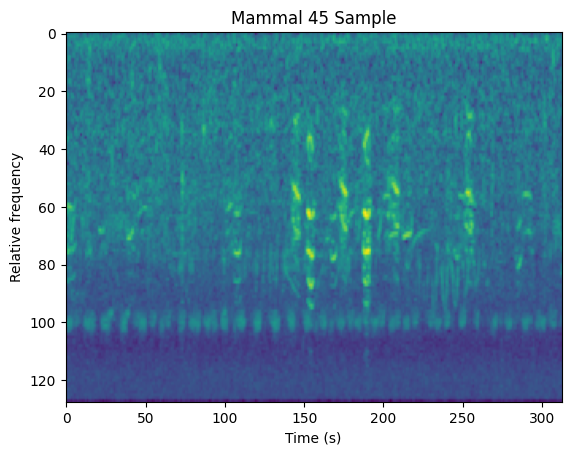

In [51]:
# This block creates a mammal spectrograms for a random training value.

import matplotlib.pyplot as plt
from random import randint

value = randint(0, len(X_train) - 1)

plt.imshow(X_train[value].squeeze(), aspect='auto')
plt.title("Mammal " + str(value) + " Sample")
plt.xlabel("Time (s)")
plt.ylabel("Relative frequency")
plt.show()


In [ ]:
# At this point, the model classifies the common mammals quite well. We now move on to the rare mammals.
# Each one uses anomaly detection.

[0.12653062 0.20612244 0.15714286 0.04897959 0.4632653 ]


In [55]:
rare_mammals

['209233', '738183', '74580']

In [71]:
# The rare classes are so rare that it is simply not worth doing an entire CNN for each of them.
# Instead, if we get a new ogg file, we simply compare it to the examples that we already have.

train_soundscapes_209233 = []
train_soundscapes_738183 = []
train_soundscapes_74580 = []

for entry in train_soundscapes_mammals_df.itertuples():
    primary_labels = entry.primary_label.split(';')
    
    for label in primary_labels:
        if label == '209233':
            train_soundscapes_209233 += [entry.filename]
        if label == '738183':
            train_soundscapes_738183 += [entry.filename]
        if label == '74580':
            train_soundscapes_74580 += [entry.filename]

In [72]:
train_soundscapes_209233

[]

In [73]:
train_soundscapes_738183

[]

In [74]:
train_soundscapes_74580

[]

In [75]:
# train_soundscapes_mammals does not contain ANY of the rare mammals.

for entry in mammal_audio_df.itertuples():
    label = entry.primary_label
    if label == 209233:
        train_soundscapes_209233 += [entry.filename]
    if label == 738183:
        train_soundscapes_738183 += [entry.filename]
    if label == 74580:
        train_soundscapes_74580 += [entry.filename]

In [76]:
train_soundscapes_209233

['209233/iNat864998.ogg']

In [79]:
train_soundscapes_738183

['738183/XC999131.ogg',
 '738183/iNat507316.ogg',
 '738183/iNat507314.ogg',
 '738183/iNat492616.ogg',
 '738183/iNat1468130.ogg']

In [80]:
train_soundscapes_74580

['74580/iNat717618.ogg', '74580/XC991442.ogg']

In [82]:
# We convert each entry in these files into a .ogg file and record them.
# We also break these files into 5 second chunks.

count = 0
X_209233 = []
X_738183 = []
X_74580 = []

EXPECTED_FRAMES = int(np.ceil((SR * 5) / 512))

for filename in train_soundscapes_209233:
    
    audio, _ = librosa.load(
        f"train_audio/{filename}",
        sr=SR
    )

    chunk_length = 5 * SR
    
    # In animal_class_classifier, we ensured that all of the ogg files were at least five seconds long.
    audio_clips = []
    for i in range(int(len(audio)/chunk_length)):
        audio_clips += [audio[i*chunk_length:(i + 1)*chunk_length]]

    # Converts the audio files in audio_clips to a mel spectrogram, and normalizes it to the range [0, 1].

    for audio_clip in audio_clips:

        mel = librosa.feature.melspectrogram(
            y=audio_clip,
            sr=SR,
            n_mels=N_MELS
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Pad / trim
        if mel_db.shape[1] < EXPECTED_FRAMES:
            mel_db = np.pad(mel_db, ((0, 0), (0, EXPECTED_FRAMES - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :EXPECTED_FRAMES]

        X_209233.append(mel_db[..., np.newaxis])

X_209233 = np.array(X_209233, dtype=np.float32)

for filename in train_soundscapes_738183:
    
    audio, _ = librosa.load(
        f"train_audio/{filename}",
        sr=SR
    )
    
    # In animal_class_classifier, we ensured that all of the ogg files were at least five seconds long.
    audio_clips = []
    for i in range(int(len(audio)/chunk_length)):
        audio_clips += [audio[i*chunk_length:(i + 1)*chunk_length]]

    # Converts the audio files in audio_clips to a mel spectrogram, and normalizes it to the range [0, 1].

    for audio_clip in audio_clips:

        mel = librosa.feature.melspectrogram(
            y=audio_clip,
            sr=SR,
            n_mels=N_MELS
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Pad / trim
        if mel_db.shape[1] < EXPECTED_FRAMES:
            mel_db = np.pad(mel_db, ((0, 0), (0, EXPECTED_FRAMES - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :EXPECTED_FRAMES]

        X_738183.append(mel_db[..., np.newaxis])

X_738183 = np.array(X_738183, dtype=np.float32)

for filename in train_soundscapes_74580:
    
    audio, _ = librosa.load(
        f"train_audio/{filename}",
        sr=SR
    )
    
    # In animal_class_classifier, we ensured that all of the ogg files were at least five seconds long.
    audio_clips = []
    for i in range(int(len(audio)/chunk_length)):
        audio_clips += [audio[i*chunk_length:(i + 1)*chunk_length]]

    # Converts the audio files in audio_clips to a mel spectrogram, and normalizes it to the range [0, 1].

    for audio_clip in audio_clips:

        mel = librosa.feature.melspectrogram(
            y=audio_clip,
            sr=SR,
            n_mels=N_MELS
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Pad / trim
        if mel_db.shape[1] < EXPECTED_FRAMES:
            mel_db = np.pad(mel_db, ((0, 0), (0, EXPECTED_FRAMES - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :EXPECTED_FRAMES]

        X_74580.append(mel_db[..., np.newaxis])

X_74580 = np.array(X_74580, dtype=np.float32)

In [83]:
len(X_209233)

3

In [84]:
len(X_738183)

75

In [85]:
len(X_74580)

11

In [154]:
# X_209233, X_738183, and X_74580 have 3, 75, and 11 mel spectrograms, respectively.
# To determine if a new spectrogram goes in one of these classes, we determine if it similar to an element in one of these sets.

# prototypes: list of arrays, one per class
# each element = array of spectrograms for that class

from sklearn.metrics.pairwise import cosine_similarity

feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output
    )

def build_prototype_matrix(X_proto):
    emb = feature_model.predict(X_proto)   # (N, D)
    emb = emb / np.linalg.norm(emb, axis=1, keepdims=True)
    return emb

proto_209233 = build_prototype_matrix(X_209233)
proto_738183 = build_prototype_matrix(X_738183)
proto_74580  = build_prototype_matrix(X_74580)

def score_against_class(x_emb, proto_matrix):
    sims = np.dot(proto_matrix, x_emb.T).squeeze()  # (1, N)
    return sims.max()

def predict_rare(x):
    # 🔹 Embed ONCE
    x_emb = feature_model.predict(x[np.newaxis, ...])  # (1, D)
    x_emb = x_emb / np.linalg.norm(x_emb, axis=1, keepdims=True)

    # 🔹 Compute all similarities (FAST)
    scores = {
        209233: score_against_class(x_emb, proto_209233),
        738183: score_against_class(x_emb, proto_738183),
        74580:  score_against_class(x_emb, proto_74580)
    }

    best_class = max(scores, key=scores.get)
    sorted_scores = sorted(scores.values(), reverse=True)

    if (
        scores[best_class] > 0.97 and
        (sorted_scores[0] - sorted_scores[1]) > 0.03
    ):
        return best_class
    else:
        return None

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [ ]:
# Detects if a new spectrogram x is similar enough to one of our current files. Outputs nothing if it is not.
# Put X_209233, X_738133, or X_74580 into prototypes.

predict_rare(X_train[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [156]:
predict_rare(X_train[-1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
